## DATA CLEANING PROJECT TASK 2

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# load dataset
file_path = "AB_NYC_2019.csv"
df = pd.read_csv(file_path)

In [15]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [17]:
# Inspect the data
print(df.shape)          # Should be (48895, 16)

(48895, 16)


In [12]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [16]:
print(df.isnull().sum())       # to detect missing values

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [18]:
#  Handle missing values
# 'last_review' has missing values → convert to datetime

df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

In [19]:
# Fill missing reviews_per_month with 0

df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [20]:
# fill small missing names

df['name'] = df['name'].fillna("Unknown")
df['host_name'] = df['host_name'].fillna("Unknown")

In [23]:
print (df.isnull().sum())

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [26]:
#  Remove duplicates

df = df.drop_duplicates()

In [28]:
# Handle price outliers

df = df[(df['price'] > 0) & (df['price'] < 10000)]

In [29]:
# Keeps only rows where minimum_nights ≤ 365

df = df[df['minimum_nights'] <= 365]

In [30]:
#   Standardize text columns

df['name'] = df['name'].str.title()
df['host_name'] = df['host_name'].str.title()
df['room_type'] = df['room_type'].str.title()
df['neighbourhood_group'] = df['neighbourhood_group'].str.title()
df['neighbourhood'] = df['neighbourhood'].str.title()

In [31]:
#  Reset the row number after filtering

df = df.reset_index(drop=True)

In [33]:
#    Detect hosts with multiple listings

duplicate_hosts = df.groupby('host_id').size().reset_index(name='listing_count')
duplicate_hosts = duplicate_hosts[duplicate_hosts['listing_count'] > 1]
print("Hosts with multiple listings:\n", duplicate_hosts.head(10))
df['is_duplicate_host'] = df['host_id'].duplicated(keep=False)

Hosts with multiple listings:
     host_id  listing_count
2      2787              6
3      2845              2
5      2881              2
10     3647              2
11     3867              2
12     4396              2
22     7351              3
27     7549              4
37     9744              3
38    10135              2


In [36]:
#  Listings with 0 reviews but non-zero reviews_per_month

zero_reviews_flag = df[(df['number_of_reviews'] == 0) & (df['reviews_per_month'] > 0)]
print("Listings with 0 reviews but non-zero reviews_per_month:", zero_reviews_flag.shape[0])


Listings with 0 reviews but non-zero reviews_per_month: 0


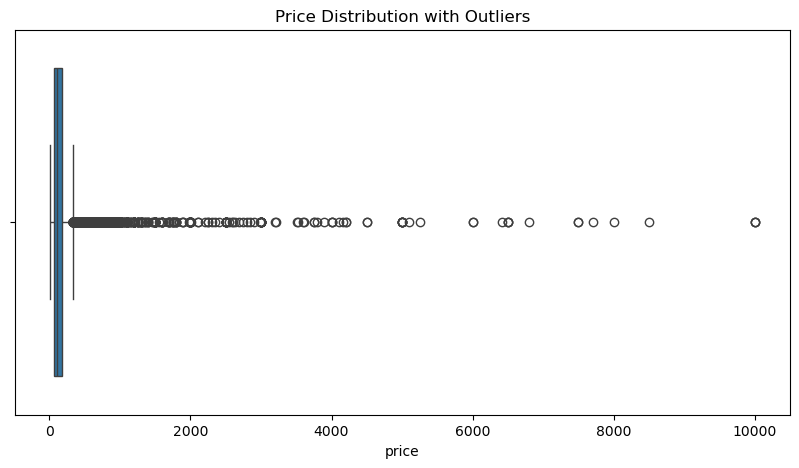

In [34]:
#   Visualize price outliers

plt.figure(figsize=(10,5))
sns.boxplot(x=df['price'])
plt.title('Price Distribution with Outliers')
plt.show()

Text(0.5, 1.0, 'Minimum Nights Distribution')

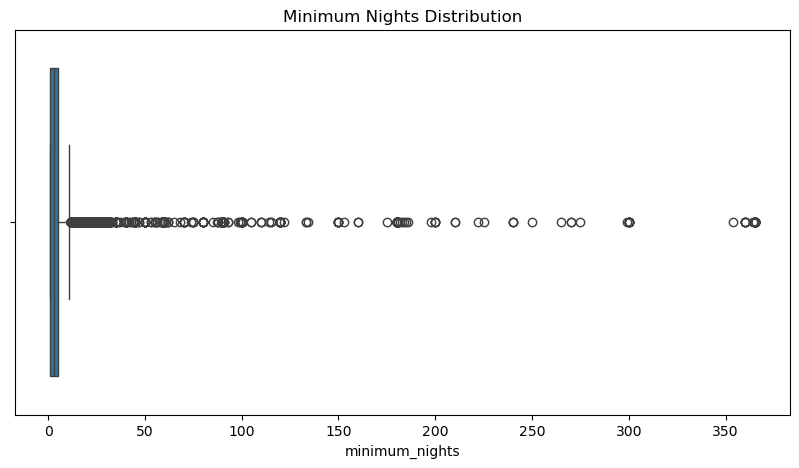

In [35]:
#   Visualize minimum_nights outliers

plt.figure(figsize=(10,5))
sns.boxplot(x=df['minimum_nights'])
plt.title('Minimum Nights Distribution')

In [37]:
#  Export cleaned CSV

clean_file_path = "AB_NYC_2019.clean.csv"
df.to_csv(clean_file_path, index=False)
print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!


In [38]:
#  Final check
print("Cleaned dataset shape:", df.shape)
print(df.head())

Cleaned dataset shape: (48867, 17)
     id                                              name  host_id  \
0  2539                Clean & Quiet Apt Home By The Park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               The Village Of Harlem....New York !     4632   
3  3831                   Cozy Entire Floor Of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft By Central Park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  Lisaroxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private Room    149    

In [39]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,is_duplicate_host
0,2539,Clean & Quiet Apt Home By The Park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private Room,149,1,9,2018-10-19,0.21,6,365,True
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire Home/Apt,225,1,45,2019-05-21,0.38,2,355,True
2,3647,The Village Of Harlem....New York !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private Room,150,3,0,NaT,0.00,1,365,False
3,3831,Cozy Entire Floor Of Brownstone,4869,Lisaroxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire Home/Apt,89,1,270,2019-07-05,4.64,1,194,False
4,5022,Entire Apt: Spacious Studio/Loft By Central Park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire Home/Apt,80,10,9,2018-11-19,0.10,1,0,False
